# Diabetes Prediction — Exploratory Data Analysis
**Alpha Team (Team 10) | CMPS344 Applied Data Science**

This notebook performs a comprehensive EDA on the transformed diabetes dataset, covering:
1. Dataset overview & class distribution
2. Univariate distributions of continuous features
3. Categorical feature breakdowns
4. Feature-to-target analysis (diabetic vs. non-diabetic)
5. Correlation & multivariate relationships
6. Engineered features analysis
7. Risk factors & clinical insights

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

# ── Styling ────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 130,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})

PALETTE = {'No Diabetes': '#4C9BE8', 'Diabetes': '#E8534C'}
C0, C1 = '#4C9BE8', '#E8534C'

print('Libraries loaded ✓')

Libraries loaded ✓


In [2]:
# ── Load data ──────────────────────────────────────────────────────────────────
df = pd.read_csv('../../data/EDA/transformed_for_eda.csv')

df['diabetes_label'] = df['diabetes'].map({0: 'No Diabetes', 1: 'Diabetes'})

print(f'Dataset shape : {df.shape}')
print(f'Diabetic      : {df["diabetes"].sum():,}  ({df["diabetes"].mean()*100:.1f}%)')
print(f'Non-diabetic  : {(df["diabetes"]==0).sum():,}  ({(1-df["diabetes"].mean())*100:.1f}%)')
df.head()

Dataset shape : (95914, 21)
Diabetic      : 8,480  (8.8%)
Non-diabetic  : 87,434  (91.2%)


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes,hba1c_category,...,blood_glucose_category,glucose_hba1c_interaction,age_hba1c_interaction,age_bmi_interaction,bmi_hba1c_interaction,age_glucose_interaction,high_hba1c_flag,senior_flag,cardio_risk_flag,diabetes_label
0,Female,80.0,0,1,never,25.19,6.6,140,0,Diabetes,...,Prediabetes,924.0,528.0,2015.20,166.254,11200.0,1,1,1,No Diabetes
1,Female,54.0,0,0,No Info,27.32,6.6,80,0,Diabetes,...,Normal,528.0,356.4,1475.28,180.312,4320.0,1,0,0,No Diabetes
2,Male,28.0,0,0,never,27.32,5.7,158,0,Prediabetes,...,Prediabetes,900.6,159.6,764.96,155.724,4424.0,0,0,0,No Diabetes
3,Female,36.0,0,0,current,23.45,5.0,155,0,Normal,...,Prediabetes,775.0,180.0,844.20,117.250,5580.0,0,0,0,No Diabetes
4,Male,76.0,1,1,current,20.14,4.8,155,0,Normal,...,Prediabetes,744.0,364.8,1530.64,96.672,11780.0,0,1,1,No Diabetes


---
## 1  Dataset Overview & Class Distribution

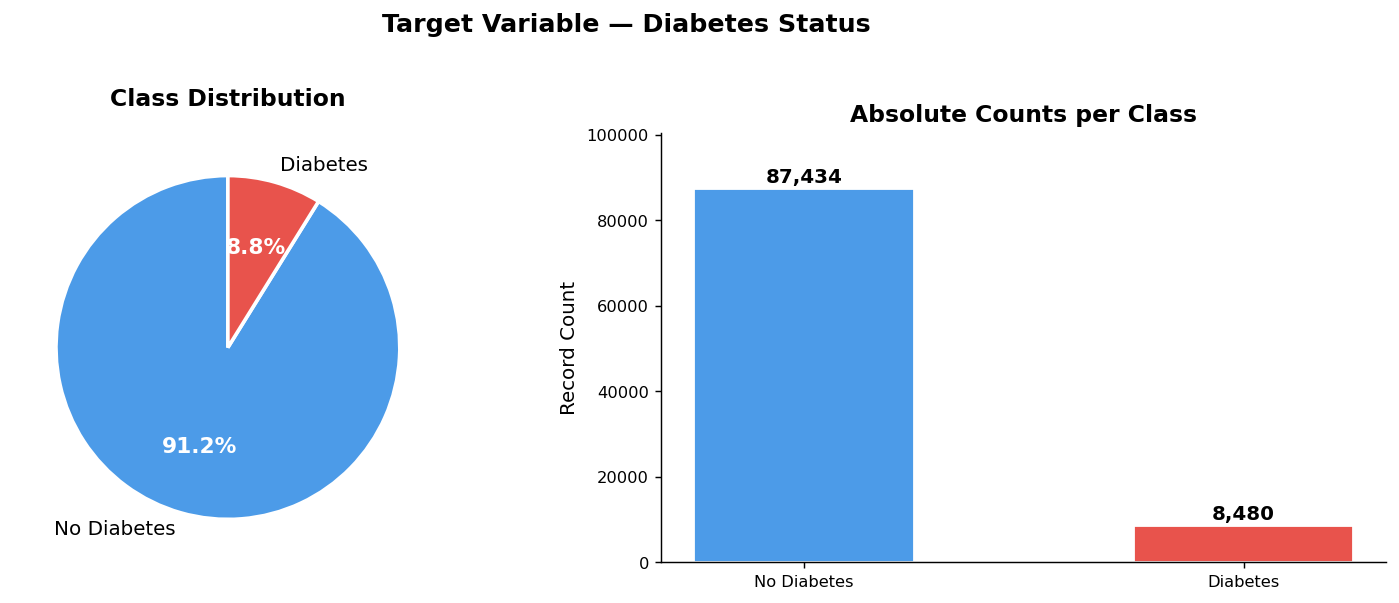


  Class Imbalance: The dataset is heavily skewed (~91.2% negative).
   Imbalance handling (e.g., SMOTE, class_weight) will be required during modelling.


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Pie chart
counts = df['diabetes'].value_counts().sort_index()
labels = ['No Diabetes', 'Diabetes']
colors = [C0, C1]
wedges, texts, autotexts = axes[0].pie(
    counts, labels=labels, autopct='%1.1f%%',
    colors=colors, startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 11}
)
for at in autotexts:
    at.set_fontsize(12); at.set_fontweight('bold'); at.set_color('white')
axes[0].set_title('Class Distribution', fontweight='bold', pad=15)

# Bar chart with counts
bars = axes[1].bar(labels, counts.values, color=colors, width=0.5, edgecolor='white')
for bar, val in zip(bars, counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                 f'{val:,}', ha='center', va='bottom', fontweight='bold', fontsize=11)
axes[1].set_ylabel('Record Count')
axes[1].set_title('Absolute Counts per Class', fontweight='bold')
axes[1].set_ylim(0, counts.max() * 1.15)

fig.suptitle('Target Variable — Diabetes Status', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('\n  Class Imbalance: The dataset is heavily skewed (~91.2% negative).')
print('   Imbalance handling (e.g., SMOTE, class_weight) will be required during modelling.')

---
## 2  Univariate Distributions — Continuous Features

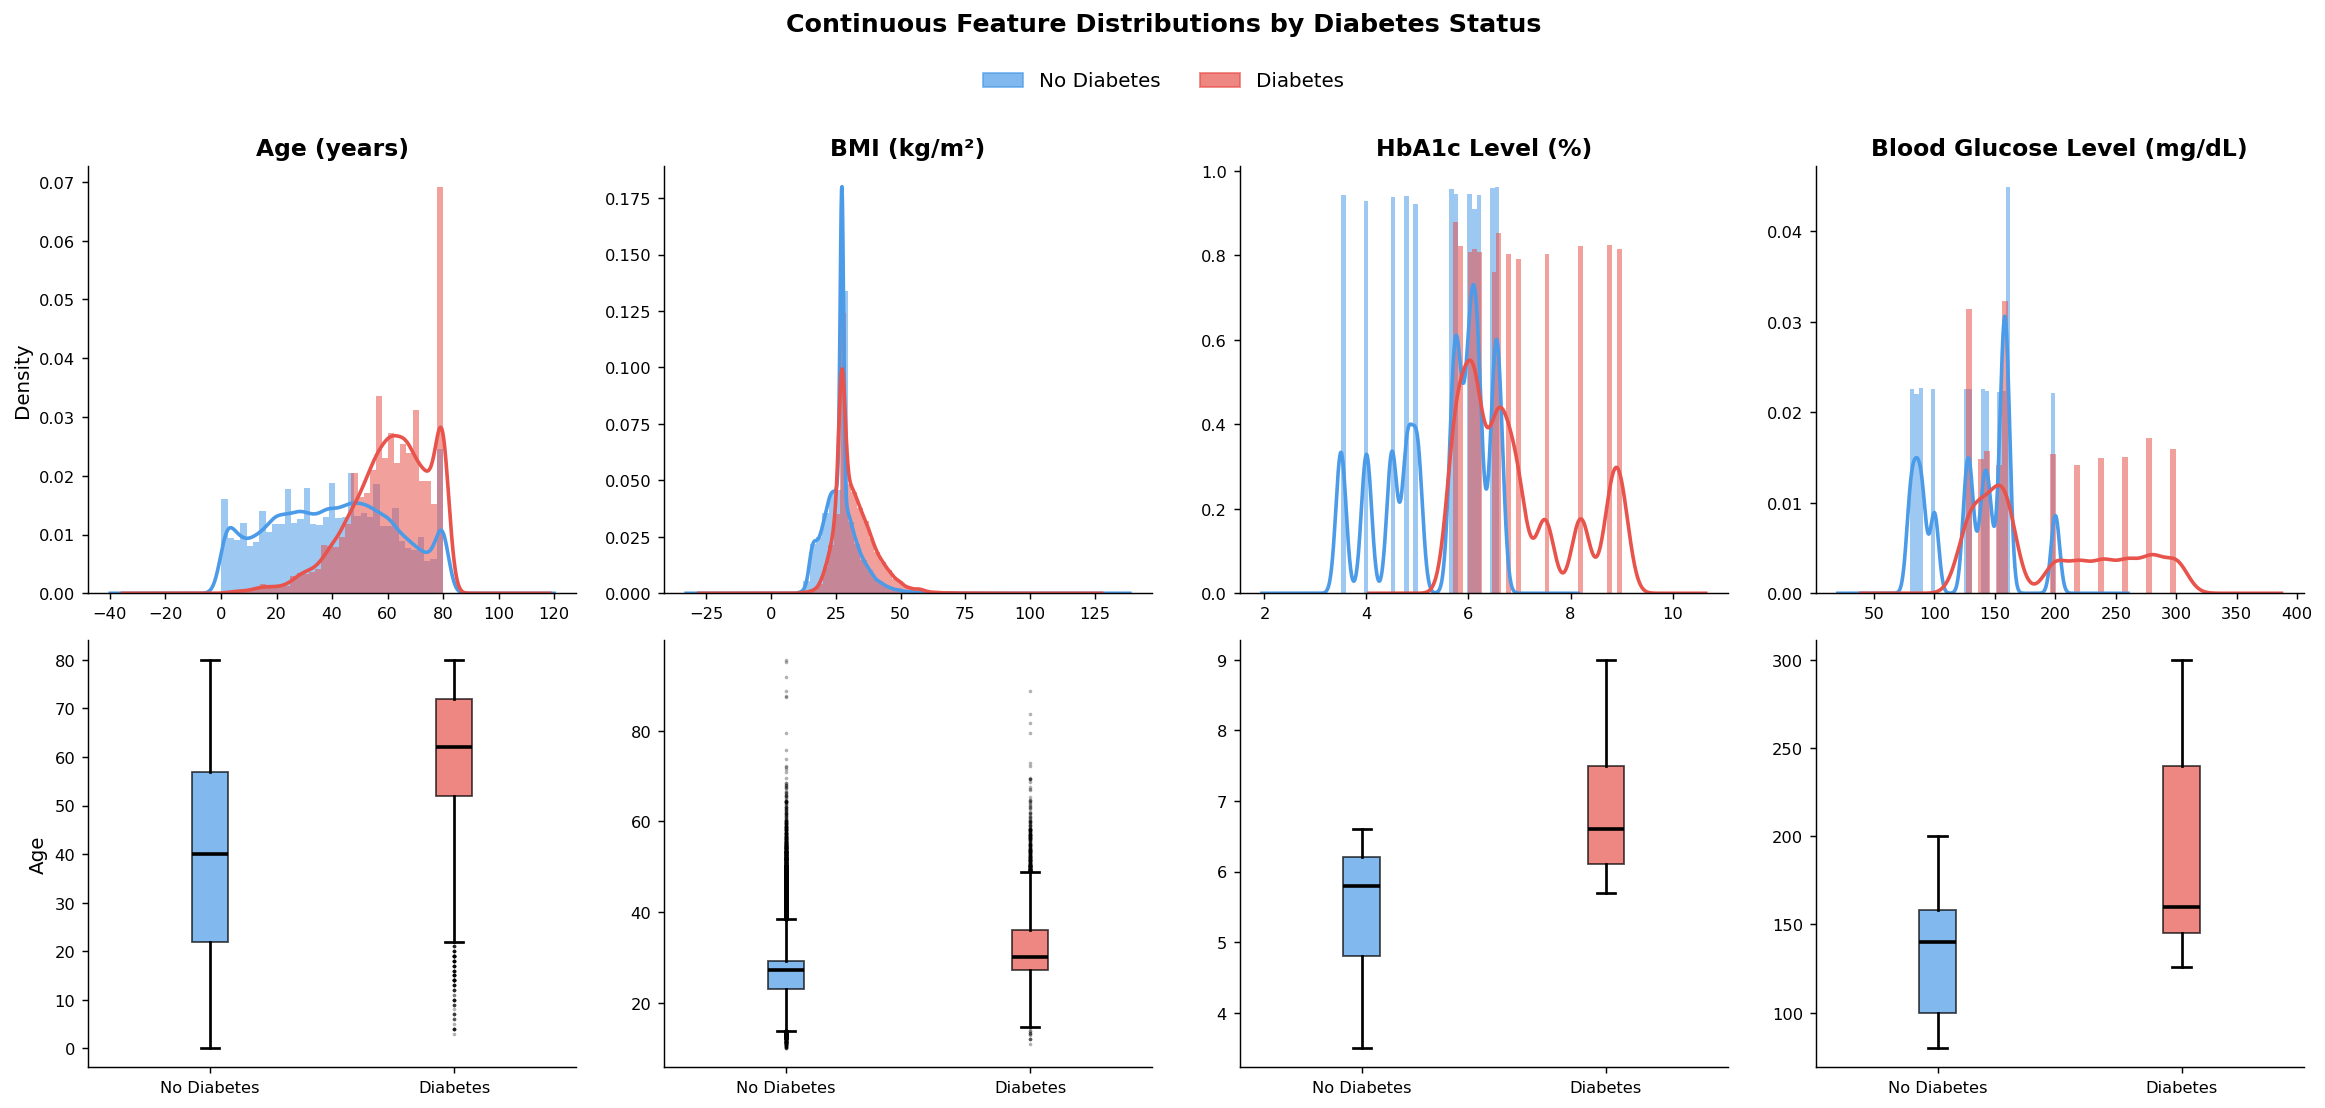


Key Observations:
  age                     No-DM mean=40.03  |  DM mean=60.94  |  Δ=+20.91
  bmi                     No-DM mean=26.89  |  DM mean=32.00  |  Δ=+5.11
  HbA1c_level             No-DM mean=5.40  |  DM mean=6.93  |  Δ=+1.54
  blood_glucose_level     No-DM mean=132.81  |  DM mean=194.01  |  Δ=+61.20


In [4]:
cont_features = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']
feat_titles = ['Age (years)', 'BMI (kg/m²)', 'HbA1c Level (%)', 'Blood Glucose Level (mg/dL)']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for i, (col, title) in enumerate(zip(cont_features, feat_titles)):
    ax_hist = axes[0, i]
    ax_box  = axes[1, i]

    # Histogram with KDE per class
    for label, color in zip([0, 1], [C0, C1]):
        subset = df[df['diabetes'] == label][col]
        ax_hist.hist(subset, bins=35, alpha=0.55, color=color,
                     density=True, edgecolor='none')
        subset.plot.kde(ax=ax_hist, color=color, linewidth=2)

    ax_hist.set_title(title, fontweight='bold')
    ax_hist.set_xlabel('')
    ax_hist.set_ylabel('Density' if i == 0 else '')

    # Box plot per class
    data_plot = [df[df['diabetes'] == 0][col], df[df['diabetes'] == 1][col]]
    bp = ax_box.boxplot(data_plot, patch_artist=True,
                        medianprops={'color': 'black', 'linewidth': 2},
                        whiskerprops={'linewidth': 1.5},
                        capprops={'linewidth': 1.5},
                        flierprops={'marker': '.', 'markersize': 2, 'alpha': 0.3})
    for patch, color in zip(bp['boxes'], [C0, C1]):
        patch.set_facecolor(color); patch.set_alpha(0.7)
    ax_box.set_xticklabels(['No Diabetes', 'Diabetes'], fontsize=9)
    ax_box.set_ylabel(title.split('(')[0].strip() if i == 0 else '')

# Legend
handles = [
    mpatches.Patch(color=C0, alpha=0.7, label='No Diabetes'),
    mpatches.Patch(color=C1, alpha=0.7, label='Diabetes')
]
fig.legend(handles=handles, loc='upper center', ncol=2,
           bbox_to_anchor=(0.5, 1.02), fontsize=11, frameon=False)

fig.suptitle('Continuous Feature Distributions by Diabetes Status',
             fontsize=14, fontweight='bold', y=1.06)
plt.tight_layout()
plt.show()

print('\nKey Observations:')
for col in cont_features:
    m0 = df[df['diabetes']==0][col].mean()
    m1 = df[df['diabetes']==1][col].mean()
    print(f'  {col:22s}  No-DM mean={m0:.2f}  |  DM mean={m1:.2f}  |  Δ={m1-m0:+.2f}')

---
## 3  Categorical Feature Analysis

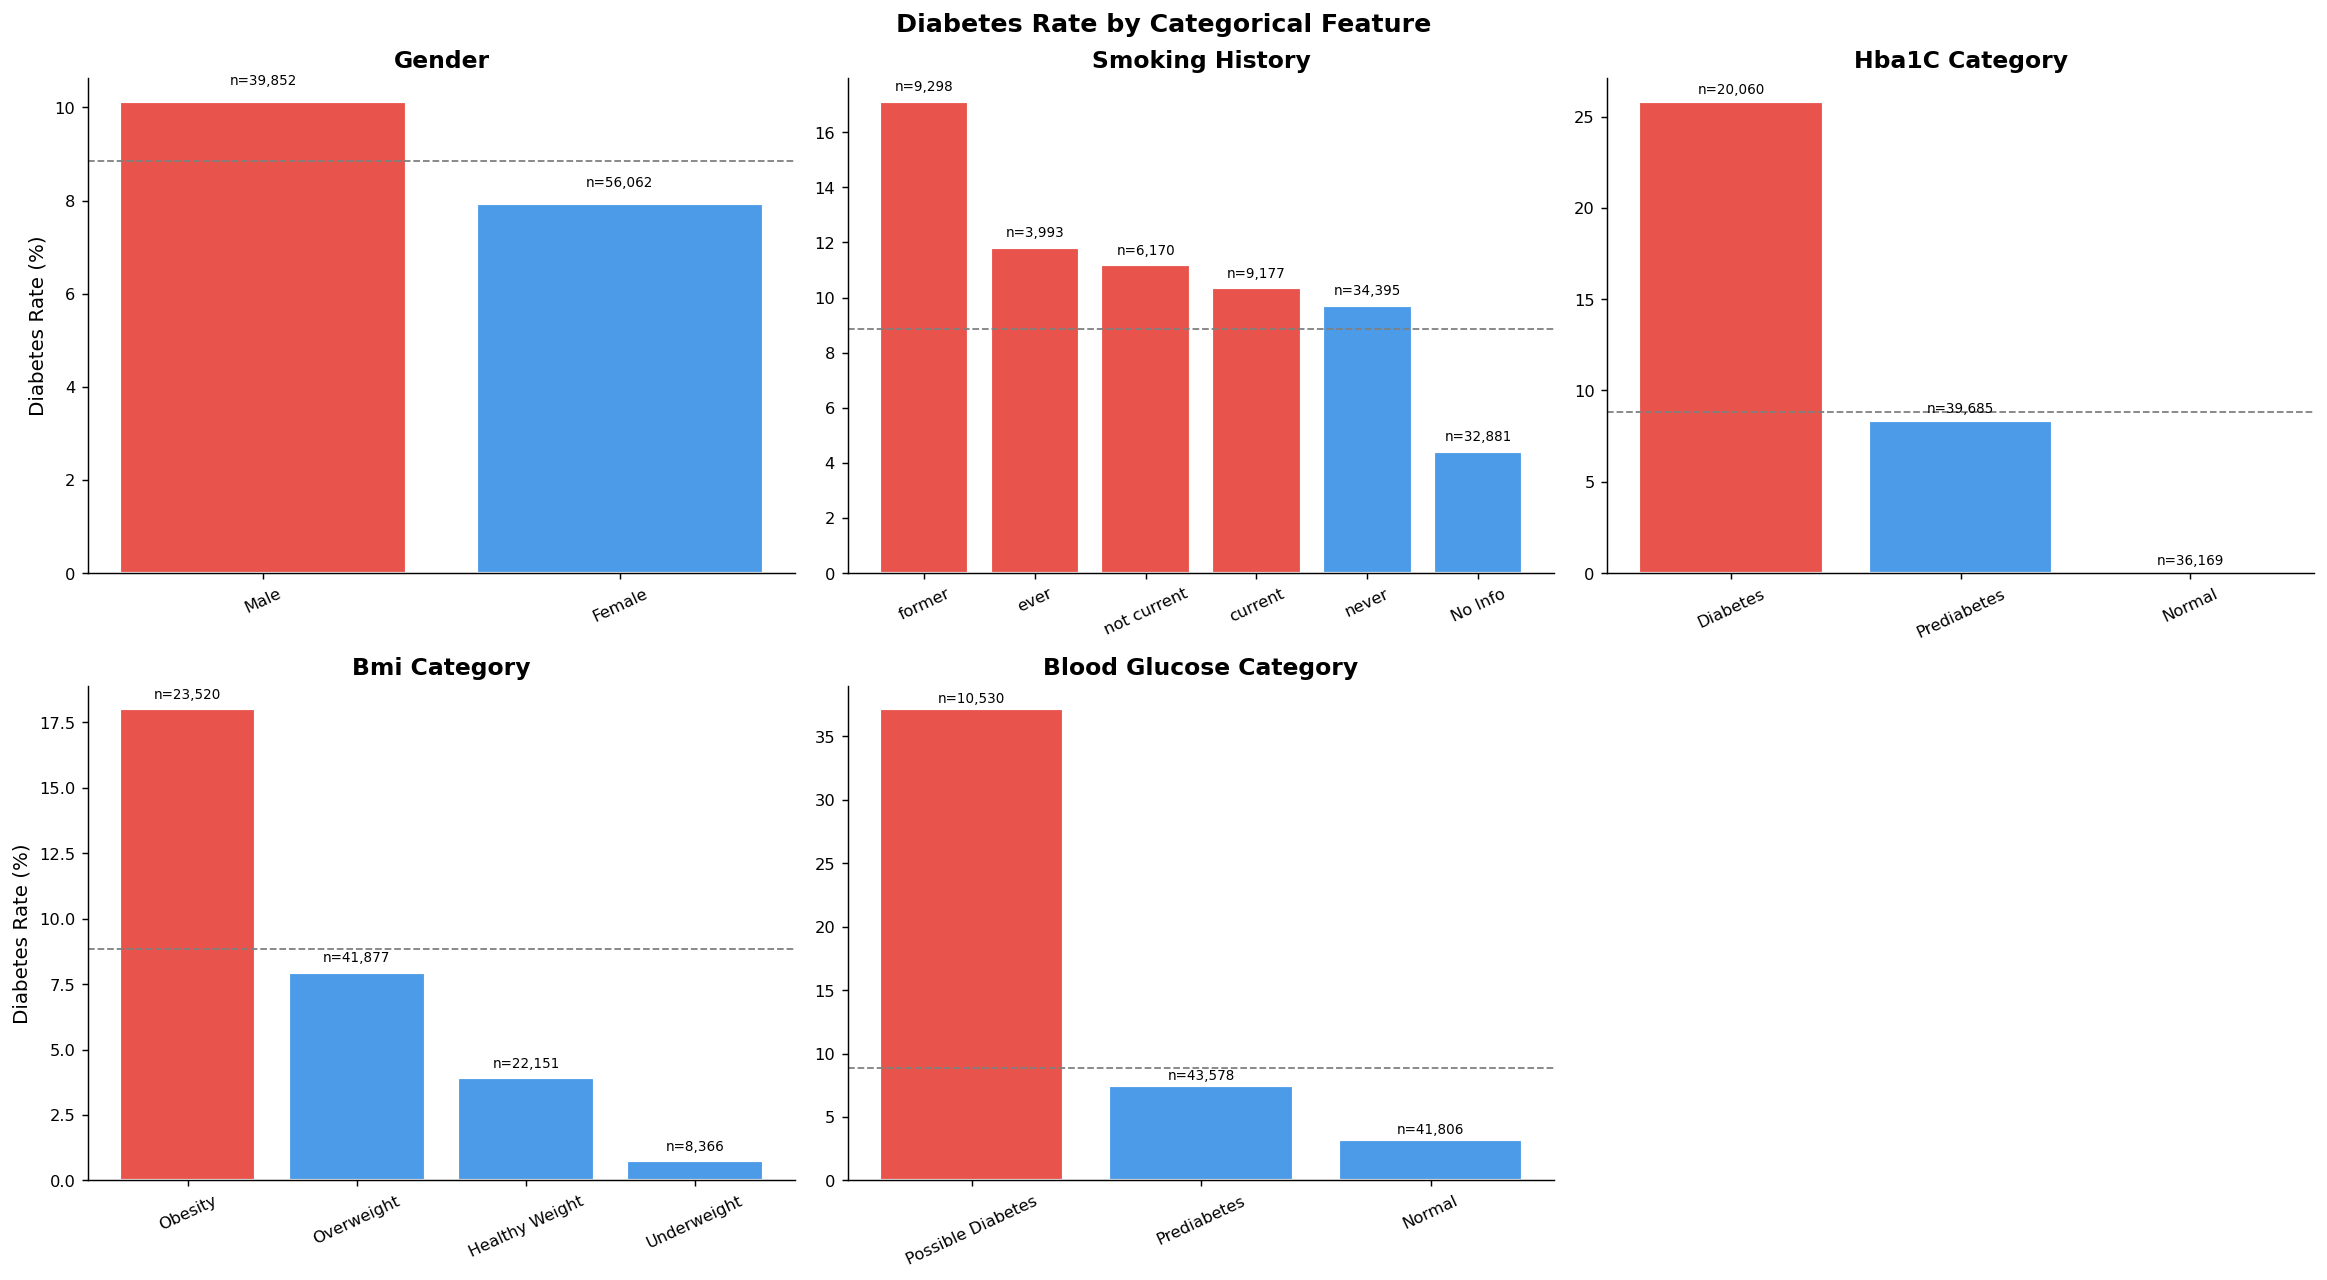

In [5]:
cat_features = ['gender', 'smoking_history', 'hba1c_category', 'bmi_category', 'blood_glucose_category']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    ax = axes[i]
    # Compute diabetes rate per category
    grp = df.groupby(col)['diabetes'].agg(['mean', 'count']).reset_index()
    grp.columns = [col, 'diabetes_rate', 'count']
    grp = grp.sort_values('diabetes_rate', ascending=False)

    bars = ax.bar(grp[col], grp['diabetes_rate'] * 100,
                  color=[C1 if r > 0.1 else C0 for r in grp['diabetes_rate']],
                  edgecolor='white', linewidth=1.2)

    # Annotate with count
    for bar, cnt in zip(bars, grp['count']):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.3,
                f'n={cnt:,}', ha='center', va='bottom', fontsize=7.5)

    ax.set_title(col.replace('_', ' ').title(), fontweight='bold')
    ax.set_ylabel('Diabetes Rate (%)' if i % 3 == 0 else '')
    ax.tick_params(axis='x', rotation=25)
    ax.axhline(df['diabetes'].mean() * 100, color='gray',
               linestyle='--', linewidth=1, label='Overall avg')

axes[-1].set_visible(False)
fig.suptitle('Diabetes Rate by Categorical Feature', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4  Feature-to-Target Analysis — Clinical Risk Profile

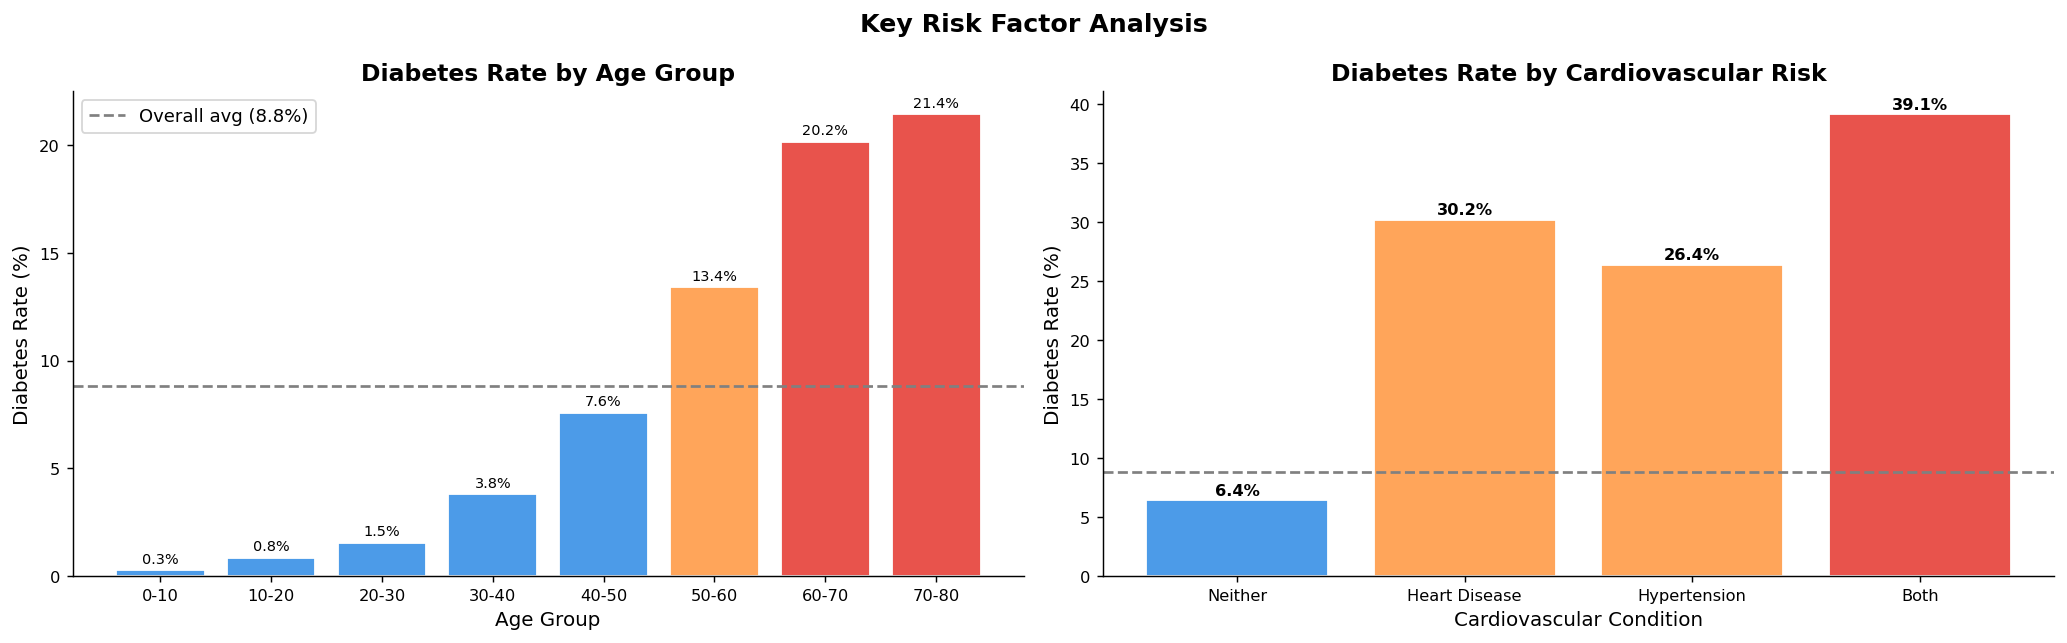

In [6]:
# Age bins vs diabetes rate
df['age_group'] = pd.cut(df['age'], bins=[0, 10, 20, 30, 40, 50, 60, 70, 80],
                          labels=['0-10','10-20','20-30','30-40','40-50','50-60','60-70','70-80'])

age_dm = df.groupby('age_group', observed=True)['diabetes'].mean() * 100
age_cnt = df.groupby('age_group', observed=True)['diabetes'].count()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Age group diabetes rate
bars = axes[0].bar(age_dm.index, age_dm.values,
                   color=[C1 if v > 15 else ('#FFA55A' if v > 8 else C0) for v in age_dm.values],
                   edgecolor='white')
axes[0].axhline(df['diabetes'].mean()*100, color='gray', linestyle='--', linewidth=1.5,
                label=f'Overall avg ({df["diabetes"].mean()*100:.1f}%)')
for bar, v in zip(bars, age_dm.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
                 f'{v:.1f}%', ha='center', va='bottom', fontsize=8)
axes[0].set_xlabel('Age Group'); axes[0].set_ylabel('Diabetes Rate (%)')
axes[0].set_title('Diabetes Rate by Age Group', fontweight='bold')
axes[0].legend()

# Hypertension + Heart Disease co-occurrence
df['cardio_status'] = (
    df[['hypertension', 'heart_disease']]
    .apply(lambda r: 'Both' if r.hypertension and r.heart_disease
           else ('Hypertension' if r.hypertension
                 else ('Heart Disease' if r.heart_disease else 'Neither')), axis=1)
)
cardio_dm = df.groupby('cardio_status')['diabetes'].mean() * 100
order = ['Neither', 'Heart Disease', 'Hypertension', 'Both']
cardio_dm = cardio_dm.reindex(order)

colors_cardio = [C0, '#FFA55A', '#FFA55A', C1]
bars2 = axes[1].bar(cardio_dm.index, cardio_dm.values, color=colors_cardio, edgecolor='white')
for bar, v in zip(bars2, cardio_dm.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
                 f'{v:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[1].axhline(df['diabetes'].mean()*100, color='gray', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Cardiovascular Condition'); axes[1].set_ylabel('Diabetes Rate (%)')
axes[1].set_title('Diabetes Rate by Cardiovascular Risk', fontweight='bold')

fig.suptitle('Key Risk Factor Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5  Correlation & Heatmap

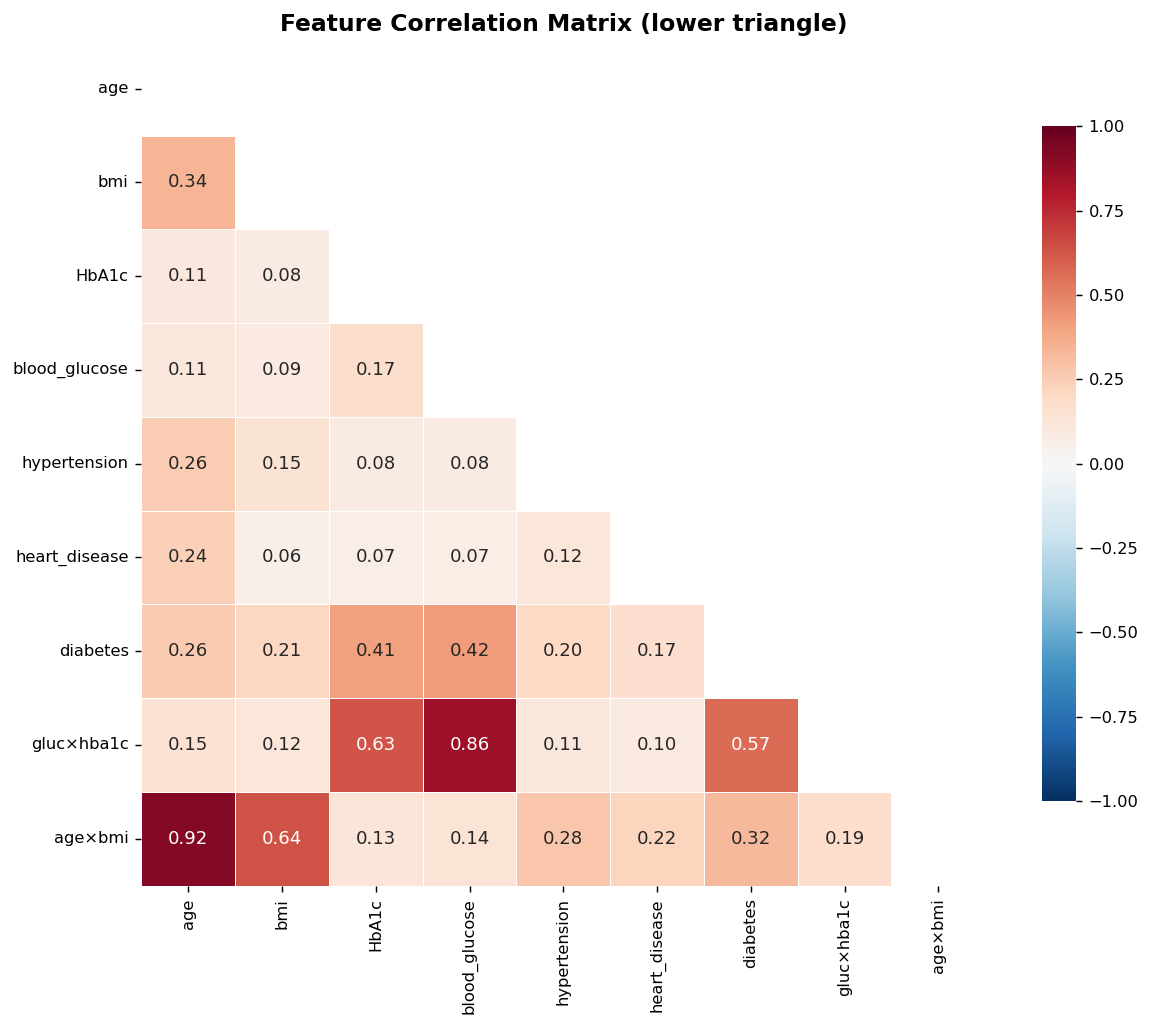


Feature correlations with diabetes (sorted by |r|):
  glucose_hba1c_interaction           +0.570  █████████████████
  blood_glucose_level                 +0.425  ████████████
  HbA1c_level                         +0.407  ████████████
  age_bmi_interaction                 +0.322  █████████
  age                                 +0.265  ███████
  bmi                                 +0.215  ██████
  hypertension                        +0.196  █████
  heart_disease                       +0.171  █████


In [7]:
num_cols = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level',
            'hypertension', 'heart_disease', 'diabetes',
            'glucose_hba1c_interaction', 'age_bmi_interaction']

corr = df[num_cols].corr()

# Rename for display
rename = {'blood_glucose_level': 'blood_glucose', 'glucose_hba1c_interaction': 'gluc×hba1c',
          'age_bmi_interaction': 'age×bmi', 'HbA1c_level': 'HbA1c'}
corr_disp = corr.rename(columns=rename, index=rename)

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_disp, dtype=bool))
sns.heatmap(corr_disp, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, ax=ax,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix (lower triangle)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

# Print top correlations with target
target_corr = corr['diabetes'].drop('diabetes').sort_values(key=abs, ascending=False)
print('\nFeature correlations with diabetes (sorted by |r|):')
for feat, val in target_corr.items():
    bar = '█' * int(abs(val) * 30)
    print(f'  {feat:35s} {val:+.3f}  {bar}')

---
## 6  Scatter & Joint Plots — Key Clinical Pairs

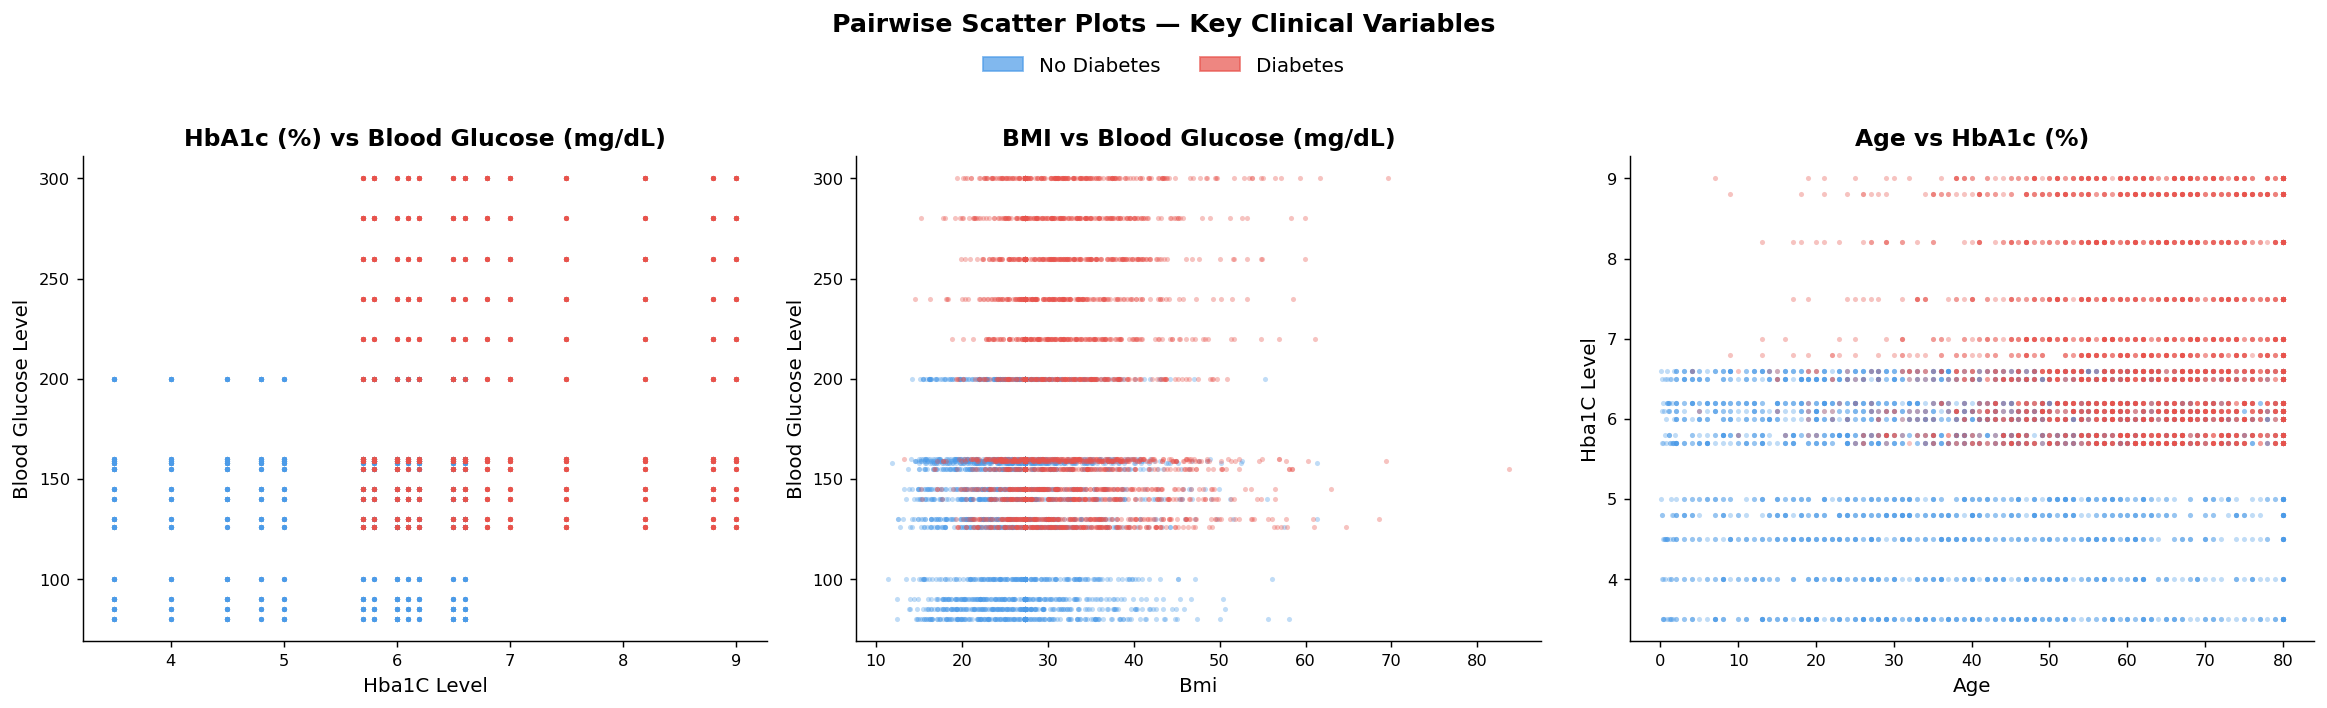

In [8]:
# Stratified sample for plotting speed
# Stratified sample - preserve diabetes column
neg = df[df['diabetes']==0].sample(3000, random_state=42)
pos = df[df['diabetes']==1].sample(min(len(df[df['diabetes']==1]), 3000), random_state=42)
sample = pd.concat([neg, pos]).reset_index(drop=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

pairs = [
    ('HbA1c_level', 'blood_glucose_level', 'HbA1c (%) vs Blood Glucose (mg/dL)'),
    ('bmi', 'blood_glucose_level', 'BMI vs Blood Glucose (mg/dL)'),
    ('age', 'HbA1c_level', 'Age vs HbA1c (%)'),
]

for ax, (x, y, title) in zip(axes, pairs):
    for label, color in zip([0, 1], [C0, C1]):
        sub = sample[sample['diabetes'] == label]
        ax.scatter(sub[x], sub[y], c=color, alpha=0.35, s=8, linewidths=0)
    ax.set_xlabel(x.replace('_', ' ').title())
    ax.set_ylabel(y.replace('_', ' ').title())
    ax.set_title(title, fontweight='bold')

handles = [
    mpatches.Patch(color=C0, alpha=0.7, label='No Diabetes'),
    mpatches.Patch(color=C1, alpha=0.7, label='Diabetes')
]
fig.legend(handles=handles, loc='upper center', ncol=2,
           bbox_to_anchor=(0.5, 1.04), fontsize=11, frameon=False)
fig.suptitle('Pairwise Scatter Plots — Key Clinical Variables', fontsize=14, fontweight='bold', y=1.08)
plt.tight_layout()
plt.show()

---
## 7  Engineered Feature Analysis

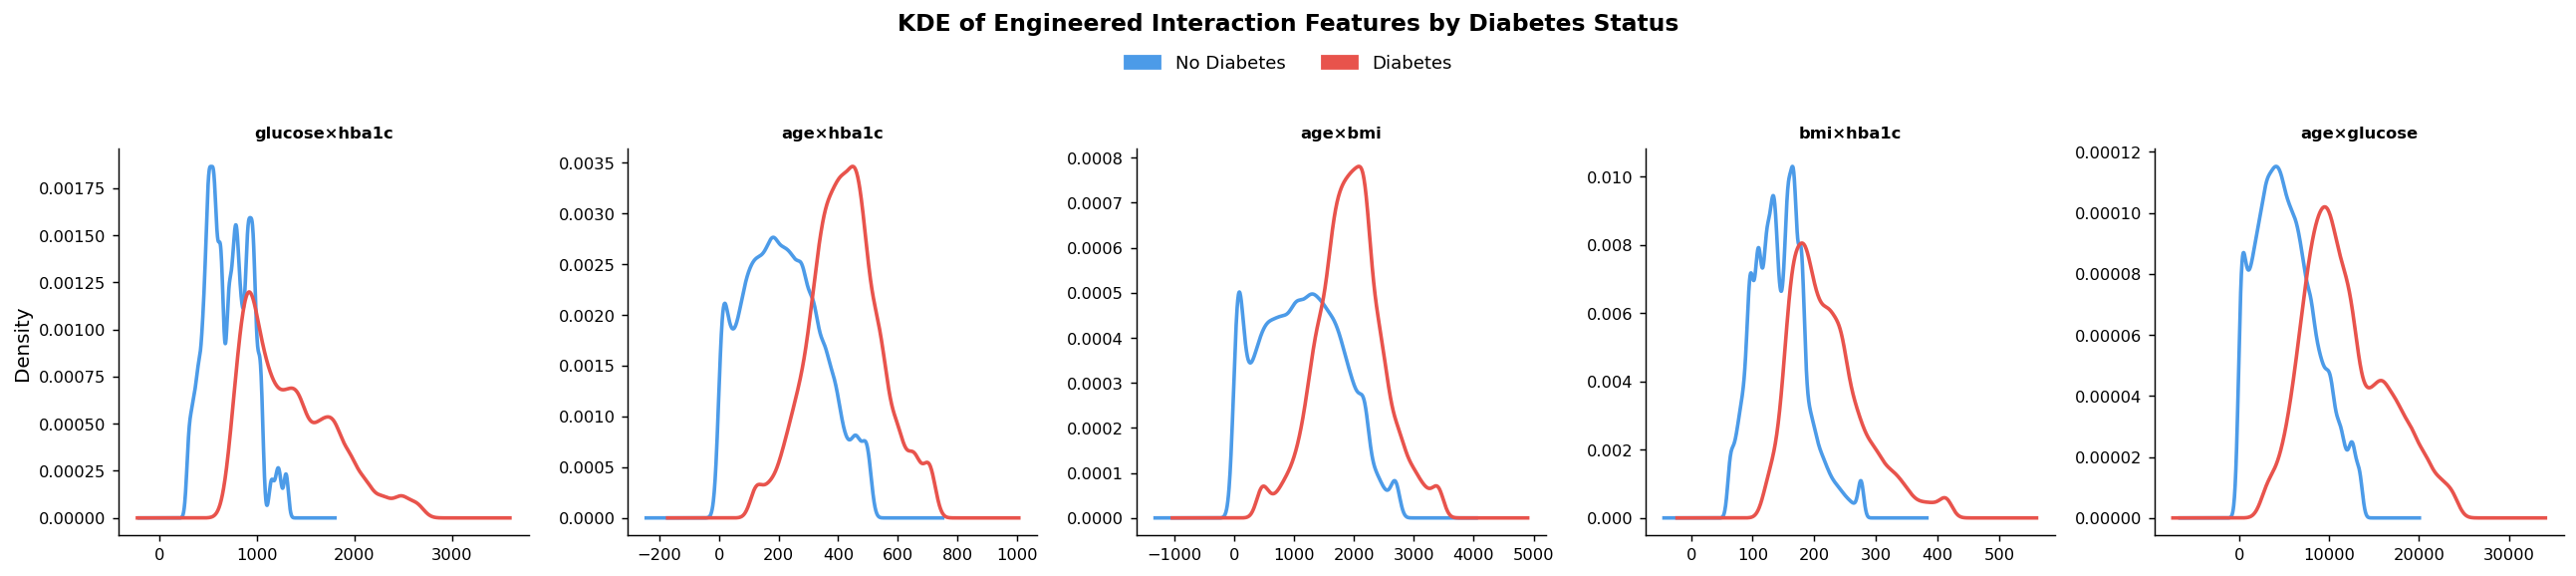

In [9]:
eng_features = ['glucose_hba1c_interaction', 'age_hba1c_interaction',
                'age_bmi_interaction', 'bmi_hba1c_interaction', 'age_glucose_interaction']

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for ax, col in zip(axes, eng_features):
    for label, color in zip([0, 1], [C0, C1]):
        subset = df[df['diabetes'] == label][col]
        # Clip extreme outliers for display
        lo, hi = subset.quantile(0.01), subset.quantile(0.99)
        subset = subset.clip(lo, hi)
        subset.plot.kde(ax=ax, color=color, linewidth=2)

    ax.set_title(col.replace('_interaction', '').replace('_', '×'), fontweight='bold', fontsize=9)
    ax.set_xlabel('')
    ax.set_ylabel('Density' if col == eng_features[0] else '')

handles = [
    mpatches.Patch(color=C0, label='No Diabetes'),
    mpatches.Patch(color=C1, label='Diabetes')
]
fig.legend(handles=handles, loc='upper center', ncol=2,
           bbox_to_anchor=(0.5, 1.05), fontsize=10, frameon=False)
fig.suptitle('KDE of Engineered Interaction Features by Diabetes Status',
             fontsize=13, fontweight='bold', y=1.1)
plt.tight_layout()
plt.show()

---
## 8  Binary Flag Analysis

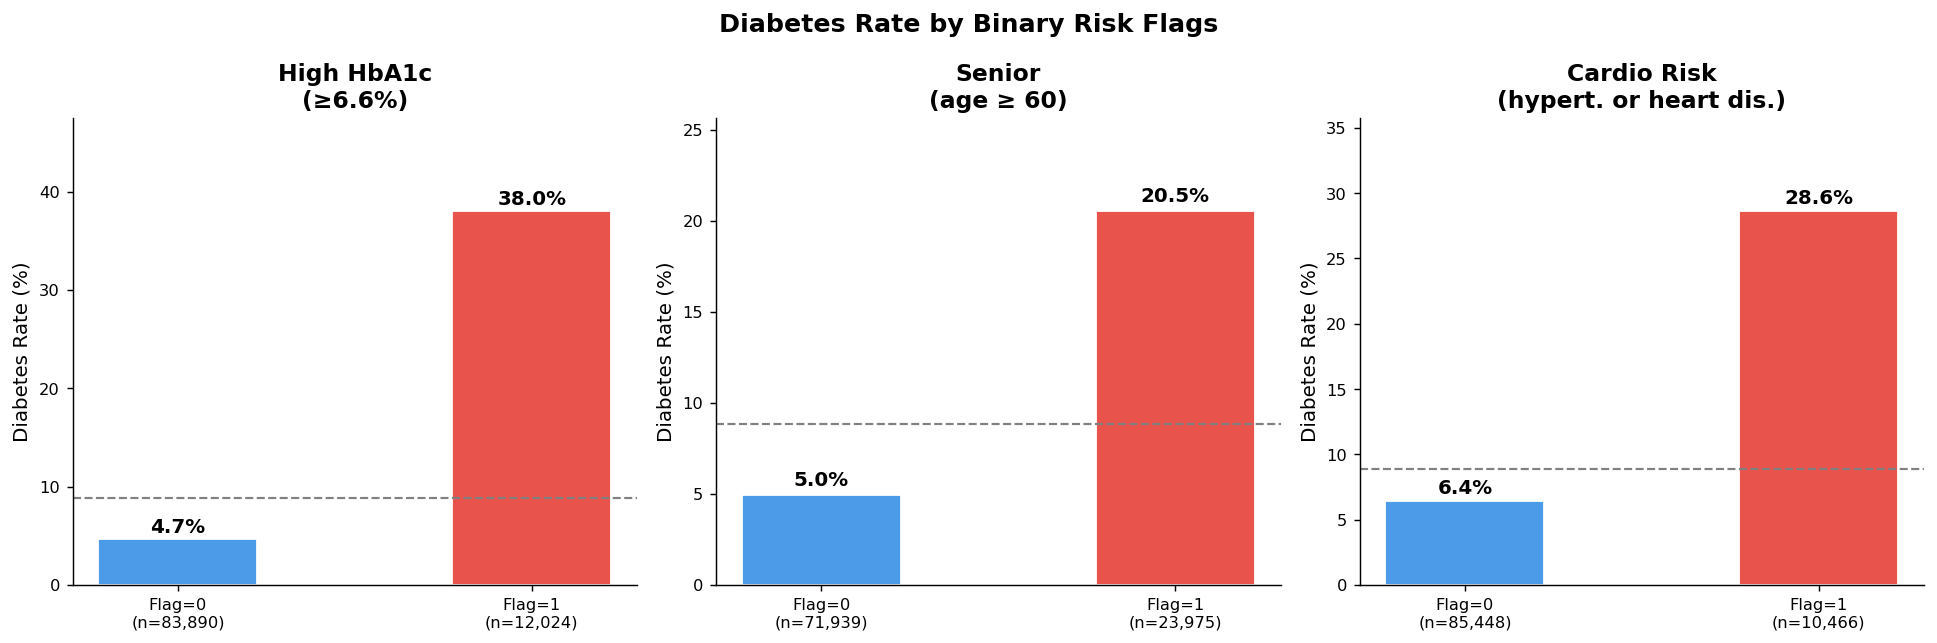

In [10]:
flags = ['high_hba1c_flag', 'senior_flag', 'cardio_risk_flag']
flag_labels = ['High HbA1c\n(≥6.6%)', 'Senior\n(age ≥ 60)', 'Cardio Risk\n(hypert. or heart dis.)']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, flag, label in zip(axes, flags, flag_labels):
    # Diabetes rate when flag=1 vs flag=0
    rates = df.groupby(flag)['diabetes'].mean() * 100
    counts = df.groupby(flag)['diabetes'].count()
    xlabels = [f'Flag=0\n(n={counts.get(0,0):,})', f'Flag=1\n(n={counts.get(1,0):,})']
    bars = ax.bar(xlabels, [rates.get(0, 0), rates.get(1, 0)],
                  color=[C0, C1], edgecolor='white', width=0.45)
    for bar, v in zip(bars, [rates.get(0, 0), rates.get(1, 0)]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                f'{v:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)
    ax.axhline(df['diabetes'].mean()*100, color='gray', linestyle='--', linewidth=1.2)
    ax.set_title(label, fontweight='bold')
    ax.set_ylabel('Diabetes Rate (%)')
    ax.set_ylim(0, max(rates.values)*1.25)

fig.suptitle('Diabetes Rate by Binary Risk Flags', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 9  Smoking History vs Diabetes (Stacked Bar)

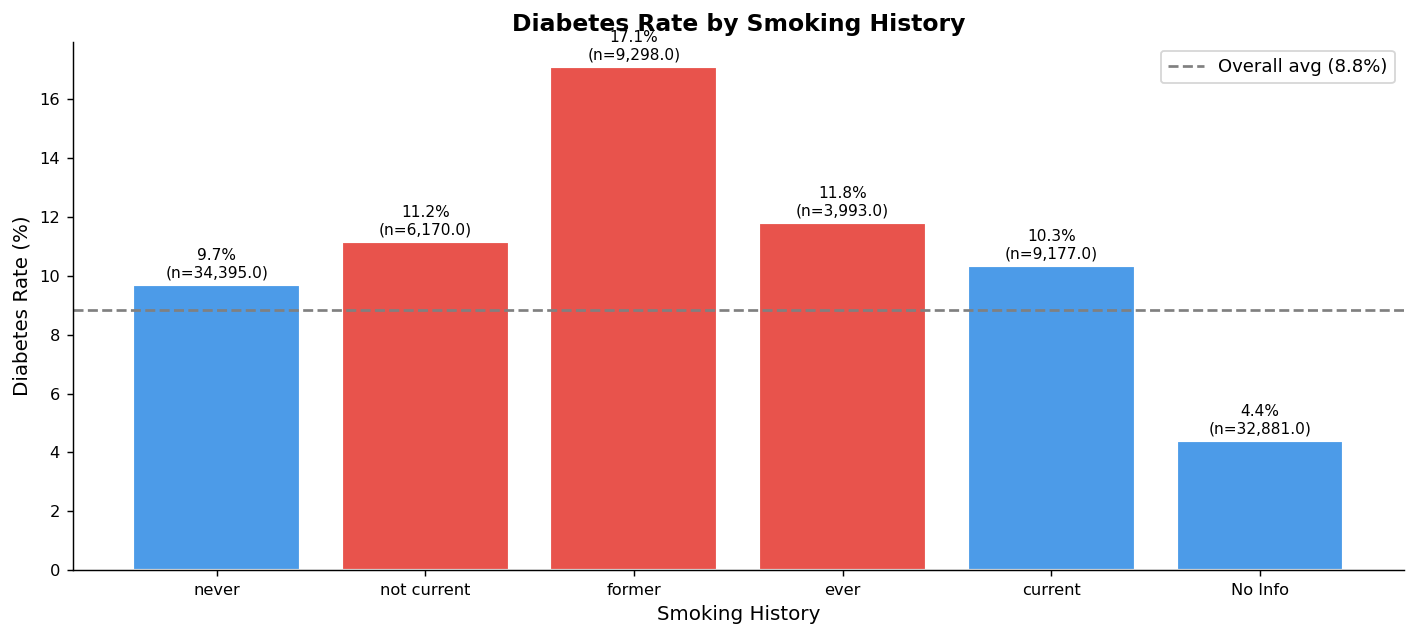

In [11]:
smoke_order = ['never', 'not current', 'former', 'ever', 'current', 'No Info']

smoke_dm = df.groupby('smoking_history')['diabetes'].agg(['mean', 'count'])
smoke_dm.columns = ['dm_rate', 'count']
smoke_dm = smoke_dm.reindex(smoke_order)

fig, ax = plt.subplots(figsize=(11, 5))

bars = ax.bar(smoke_dm.index,
              smoke_dm['dm_rate'] * 100,
              color=[C1 if v > df['diabetes'].mean()*1.2 else C0 for v in smoke_dm['dm_rate']],
              edgecolor='white', linewidth=1.2)

for bar, (_, row) in zip(bars, smoke_dm.iterrows()):
    h = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, h+0.15,
            f'{h:.1f}%\n(n={row["count"]:,})', ha='center', va='bottom', fontsize=8.5)

ax.axhline(df['diabetes'].mean()*100, color='gray', linestyle='--', linewidth=1.5,
           label=f'Overall avg ({df["diabetes"].mean()*100:.1f}%)')
ax.set_xlabel('Smoking History'); ax.set_ylabel('Diabetes Rate (%)')
ax.set_title('Diabetes Rate by Smoking History', fontweight='bold', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

---
## 10  HbA1c & Blood Glucose Category Cross-Tab (Heatmap)

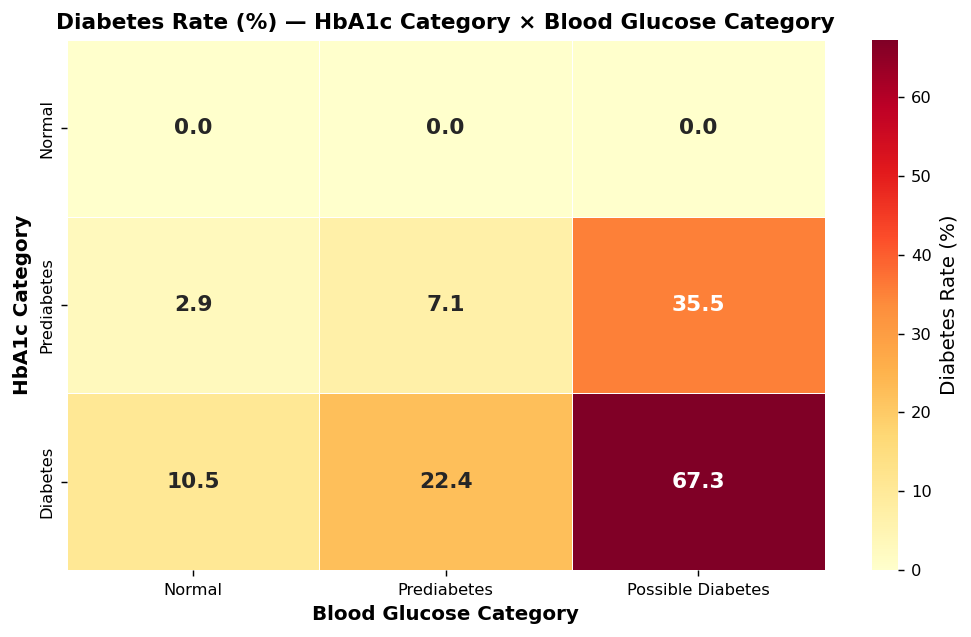


Insight: Patients in the Diabetes HbA1c range AND Possible Diabetes glucose range have the highest diabetes prevalence.


In [12]:
ct = pd.crosstab(df['hba1c_category'], df['blood_glucose_category'],
                 values=df['diabetes'], aggfunc='mean') * 100

# Reorder rows and columns clinically
row_order = [c for c in ['Normal', 'Prediabetes', 'Diabetes'] if c in ct.index]
col_order = [c for c in ['Normal', 'Prediabetes', 'Possible Diabetes'] if c in ct.columns]
ct = ct.reindex(index=row_order, columns=col_order)

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(ct, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Diabetes Rate (%)'},
            annot_kws={'size': 12, 'weight': 'bold'})
ax.set_xlabel('Blood Glucose Category', fontweight='bold')
ax.set_ylabel('HbA1c Category', fontweight='bold')
ax.set_title('Diabetes Rate (%) — HbA1c Category × Blood Glucose Category',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

print('\nInsight: Patients in the Diabetes HbA1c range AND Possible Diabetes glucose range',
      'have the highest diabetes prevalence.')

---
## 11  Gender × Age Group — Diabetes Rate Heatmap

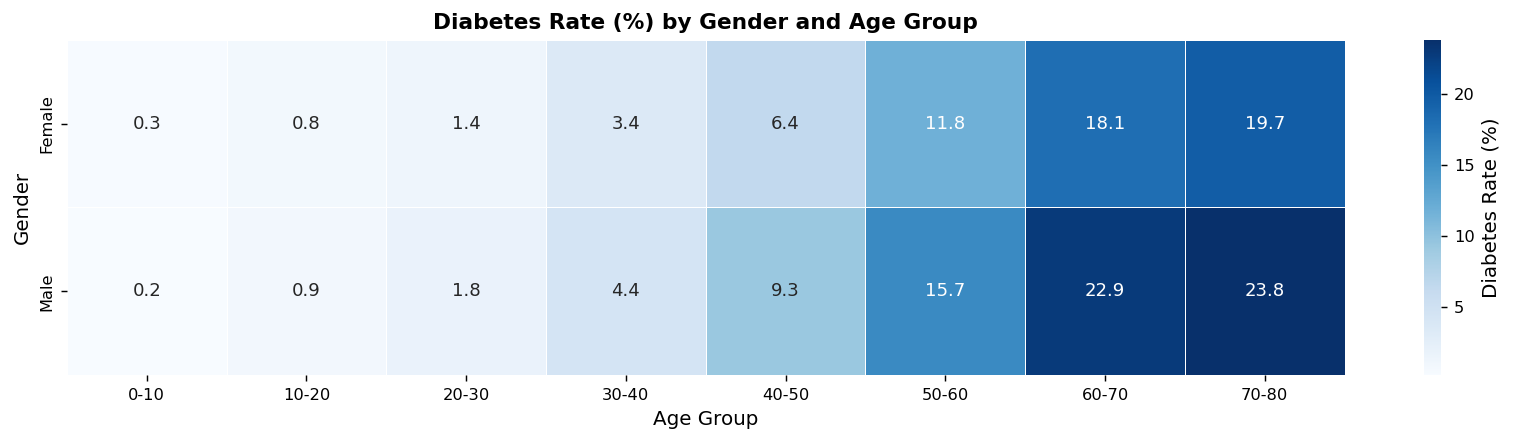

In [13]:
gender_age = df.groupby(['gender', 'age_group'], observed=True)['diabetes'].mean() * 100
gender_age_pivot = gender_age.unstack(level='age_group')

fig, ax = plt.subplots(figsize=(13, 3.5))
sns.heatmap(gender_age_pivot, annot=True, fmt='.1f', cmap='Blues', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Diabetes Rate (%)'},
            annot_kws={'size': 10})
ax.set_xlabel('Age Group'); ax.set_ylabel('Gender')
ax.set_title('Diabetes Rate (%) by Gender and Age Group', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

---
## 12  BMI Category Violin Plot

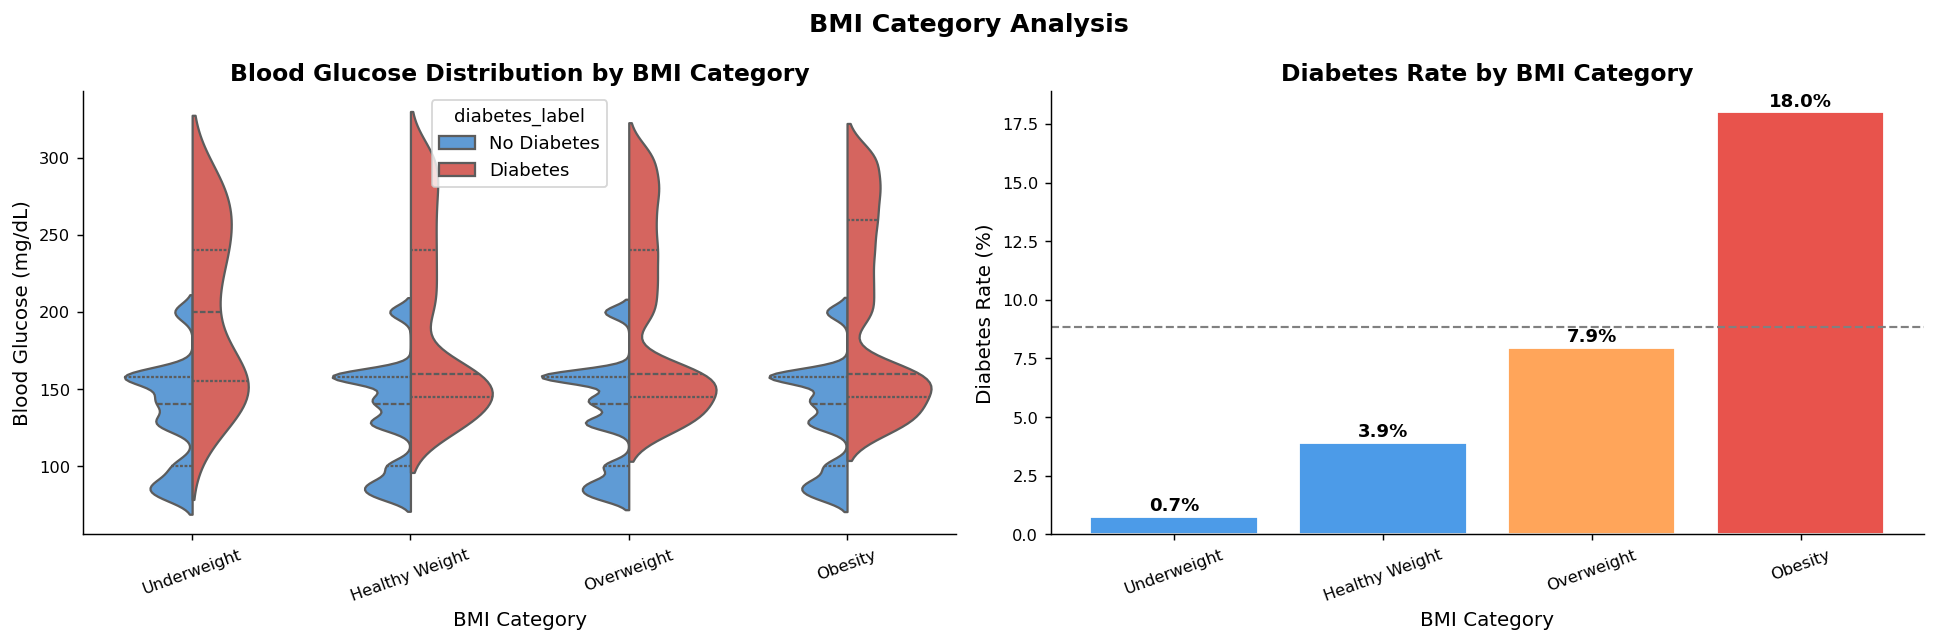

In [14]:
bmi_order = ['Underweight', 'Healthy Weight', 'Overweight', 'Obesity']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Violin: blood glucose by BMI category, split by diabetes
plot_data = df[df['bmi_category'].isin(bmi_order)].copy()
plot_data['bmi_category'] = pd.Categorical(plot_data['bmi_category'], categories=bmi_order, ordered=True)
plot_data = plot_data.sort_values('bmi_category')

sns.violinplot(data=plot_data, x='bmi_category', y='blood_glucose_level',
               hue='diabetes_label', split=True, palette=PALETTE,
               inner='quartile', ax=axes[0], order=bmi_order)
axes[0].set_title('Blood Glucose Distribution by BMI Category', fontweight='bold')
axes[0].set_xlabel('BMI Category'); axes[0].set_ylabel('Blood Glucose (mg/dL)')
axes[0].tick_params(axis='x', rotation=20)

# Diabetes rate by BMI category
bmi_dm = df.groupby('bmi_category', observed=True)['diabetes'].mean() * 100
bmi_dm = bmi_dm.reindex(bmi_order)
bars = axes[1].bar(bmi_dm.index, bmi_dm.values,
                   color=[C0, C0, '#FFA55A', C1], edgecolor='white')
for bar, v in zip(bars, bmi_dm.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                 f'{v:.1f}%', ha='center', va='bottom', fontweight='bold')
axes[1].axhline(df['diabetes'].mean()*100, color='gray', linestyle='--', linewidth=1.2)
axes[1].set_title('Diabetes Rate by BMI Category', fontweight='bold')
axes[1].set_xlabel('BMI Category'); axes[1].set_ylabel('Diabetes Rate (%)')
axes[1].tick_params(axis='x', rotation=20)

fig.suptitle('BMI Category Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 13  EDA Summary & Modelling Implications

In [15]:
print('=' * 65)
print('  EDA KEY FINDINGS — Diabetes Prediction Dataset')
print('=' * 65)

findings = [
    ('Class Imbalance',
     f'~{df["diabetes"].mean()*100:.1f}% positive class. SMOTE / class_weight required.'),
    ('Strongest predictors',
     'HbA1c_level > blood_glucose_level >> age, BMI (by correlation & mean-shift).'),
    ('Age risk',
     'Diabetes rate rises sharply after age 50; ≥60 group has highest prevalence.'),
    ('Cardiovascular co-morbidity',
     'Patients with both hypertension AND heart disease show elevated diabetes rate.'),
    ('BMI',
     'Obesity category has the highest diabetes rate; underweight the lowest.'),
    ('Clinical threshold',
     'HbA1c ≥ 6.6 % + blood glucose in "Possible Diabetes" → near-certain diabetes.'),
    ('Smoking',
     '"Former" and "ever" smokers show slightly higher rates than "never" smokers.'),
    ('Engineered features',
     'glucose×hba1c interaction shows clear separation and should benefit tree models.'),
    ('Gender',
     'Minimal difference in overall rate; males slightly higher in older age groups.'),
]

for i, (title, detail) in enumerate(findings, 1):
    print(f'\n  {i:2d}. {title}')
    print(f'      → {detail}')

print('\n' + '=' * 65)

  EDA KEY FINDINGS — Diabetes Prediction Dataset

   1. Class Imbalance
      → ~8.8% positive class. SMOTE / class_weight required.

   2. Strongest predictors
      → HbA1c_level > blood_glucose_level >> age, BMI (by correlation & mean-shift).

   3. Age risk
      → Diabetes rate rises sharply after age 50; ≥60 group has highest prevalence.

   4. Cardiovascular co-morbidity
      → Patients with both hypertension AND heart disease show elevated diabetes rate.

   5. BMI
      → Obesity category has the highest diabetes rate; underweight the lowest.

   6. Clinical threshold
      → HbA1c ≥ 6.6 % + blood glucose in "Possible Diabetes" → near-certain diabetes.

   7. Smoking
      → "Former" and "ever" smokers show slightly higher rates than "never" smokers.

   8. Engineered features
      → glucose×hba1c interaction shows clear separation and should benefit tree models.

   9. Gender
      → Minimal difference in overall rate; males slightly higher in older age groups.

